# Double Pendulum: Chaos in Classical Mechanics

## Computational Physics Final Project

---

The **double pendulum** is one of the simplest mechanical systems that exhibits rich chaotic behavior. It consists of two pendulums attached end to end: the first pendulum hangs from a fixed pivot, and the second pendulum hangs from the bob of the first.

Despite the simplicity of its construction, the double pendulum's motion is extraordinarily sensitive to initial conditions — a hallmark of **deterministic chaos**. Small changes in the starting angles or velocities lead to dramatically different trajectories over time, making long-term prediction practically impossible even though the governing equations are entirely deterministic.

In this notebook we:
1. Derive the equations of motion from first principles using **Lagrangian mechanics**.
2. Solve the coupled nonlinear ODEs numerically with both `scipy.integrate.solve_ivp` and a hand-written **4th-order Runge–Kutta** integrator.
3. Produce 2-D and 3-D visualizations, phase-space portraits, and animations.
4. Verify energy conservation and compare solver accuracy.
5. Demonstrate sensitivity to initial conditions and estimate the **Lyapunov exponent**.
6. Explore boundary and special cases, including the small-angle (linear) limit.

## 2. Physical Description of the Double Pendulum

### System Setup

A double pendulum consists of:
- **Pendulum 1**: A rigid, massless rod of length $l_1$ with a point mass $m_1$ at its end, suspended from a fixed pivot.
- **Pendulum 2**: A rigid, massless rod of length $l_2$ with a point mass $m_2$ at its end, suspended from the bob of Pendulum 1.

The angles $\theta_1$ and $\theta_2$ are measured from the downward vertical.

### Why It Is Chaotic

The equations of motion are **coupled** and **nonlinear** (they involve $\sin$ and $\cos$ of angle differences). This nonlinearity is the root cause of chaos:

- **Sensitive dependence on initial conditions**: two trajectories starting infinitesimally close diverge exponentially in time.
- **No closed-form solution**: the motion cannot be expressed in terms of elementary functions for general initial conditions.
- **Positive Lyapunov exponent**: nearby trajectories in phase space separate at an exponential rate.

### Assumptions

| # | Assumption |
|---|------------|
| 1 | Both rods are perfectly rigid and massless. |
| 2 | Masses are concentrated at points (point-mass approximation). |
| 3 | No friction at the pivots. |
| 4 | No air resistance or other dissipative forces. |
| 5 | Motion is confined to a 2-D vertical plane. |
| 6 | Gravity is uniform with acceleration $g$. |

## 3. Mathematical Background — Lagrangian Mechanics

### Generalized Coordinates

We choose $\theta_1$ and $\theta_2$ (angles from the downward vertical) as generalized coordinates.

The Cartesian positions of the two bobs are:

$$
x_1 = l_1 \sin\theta_1, \qquad y_1 = -l_1 \cos\theta_1
$$

$$
x_2 = l_1 \sin\theta_1 + l_2 \sin\theta_2, \qquad y_2 = -l_1 \cos\theta_1 - l_2 \cos\theta_2
$$

### Kinetic Energy

$$
T_1 = \tfrac{1}{2} m_1 (\dot{x}_1^2 + \dot{y}_1^2)
    = \tfrac{1}{2} m_1 l_1^2 \dot{\theta}_1^2
$$

$$
T_2 = \tfrac{1}{2} m_2 (\dot{x}_2^2 + \dot{y}_2^2)
    = \tfrac{1}{2} m_2 \bigl[
        l_1^2 \dot{\theta}_1^2
      + l_2^2 \dot{\theta}_2^2
      + 2 l_1 l_2 \dot{\theta}_1 \dot{\theta}_2 \cos(\theta_1 - \theta_2)
    \bigr]
$$

$$
T = T_1 + T_2
$$

### Potential Energy

$$
V = -m_1 g l_1 \cos\theta_1 - m_2 g (l_1 \cos\theta_1 + l_2 \cos\theta_2)
$$

### Lagrangian

$$
\mathcal{L} = T - V
$$

### Euler–Lagrange Equations

Applying $\displaystyle \frac{d}{dt}\frac{\partial \mathcal{L}}{\partial \dot{\theta}_i} - \frac{\partial \mathcal{L}}{\partial \theta_i} = 0$ for $i = 1, 2$ yields two coupled second-order ODEs.

After simplification the equations of motion are:

$$
\ddot{\theta}_1 = \frac{
  -g(2m_1+m_2)\sin\theta_1
  - m_2 g \sin(\theta_1-2\theta_2)
  - 2\sin(\theta_1-\theta_2)\,m_2\!\left(\dot{\theta}_2^2 l_2 + \dot{\theta}_1^2 l_1 \cos(\theta_1-\theta_2)\right)
}{
  l_1\!\left(2m_1+m_2-m_2\cos(2\theta_1-2\theta_2)\right)
}
$$

$$
\ddot{\theta}_2 = \frac{
  2\sin(\theta_1-\theta_2)\!\left(
    \dot{\theta}_1^2 l_1 (m_1+m_2)
    + g(m_1+m_2)\cos\theta_1
    + \dot{\theta}_2^2 l_2 m_2 \cos(\theta_1-\theta_2)
  \right)
}{
  l_2\!\left(2m_1+m_2-m_2\cos(2\theta_1-2\theta_2)\right)
}
$$

These are rewritten as a system of four first-order ODEs by introducing $\omega_i = \dot{\theta}_i$.

In [1]:
%matplotlib inline

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.animation as animation
from IPython.display import display, Image
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'axes.grid': True,
    'font.size': 12,
    'lines.linewidth': 1.5,
})

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# System parameters
m1, m2 = 1.0, 1.0        # masses (kg)
l1, l2 = 1.0, 1.0        # rod lengths (m)
g      = 9.81             # gravitational acceleration (m/s^2)

# Initial conditions
theta1_0 = np.radians(120)   # initial angle of pendulum 1 (rad)
theta2_0 = np.radians(90)    # initial angle of pendulum 2 (rad)
omega1_0 = 0.0               # initial angular velocity of pendulum 1
omega2_0 = 0.0               # initial angular velocity of pendulum 2

y0 = [theta1_0, omega1_0, theta2_0, omega2_0]

# Time span
t_start, t_end = 0.0, 30.0
dt = 0.001                    # RK4 step size
t_eval_scipy = np.arange(t_start, t_end, dt)

print(f'Parameters: m1={m1}, m2={m2}, l1={l1}, l2={l2}, g={g}')
print(f'ICs: theta1={np.degrees(theta1_0):.1f} deg, theta2={np.degrees(theta2_0):.1f} deg, omega1={omega1_0}, omega2={omega2_0}')
print(f'Integration window: {t_start} - {t_end} s   (dt = {dt})')

Parameters: m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81
ICs: theta1=120.0 deg, theta2=90.0 deg, omega1=0.0, omega2=0.0
Integration window: 0.0 - 30.0 s   (dt = 0.001)


In [3]:
def double_pendulum_derivs(t, y, m1=m1, m2=m2, l1=l1, l2=l2, g=g):
    """Equations of motion for the double pendulum.
    State vector: y = [theta1, omega1, theta2, omega2]
    Returns: dy/dt
    """
    th1, w1, th2, w2 = y
    delta = th1 - th2
    sin_d, cos_d = np.sin(delta), np.cos(delta)
    den = 2*m1 + m2 - m2*np.cos(2*delta)

    dw1 = (-g*(2*m1+m2)*np.sin(th1)
            - m2*g*np.sin(th1 - 2*th2)
            - 2*sin_d*m2*(w2**2*l2 + w1**2*l1*cos_d)) / (l1*den)

    dw2 = (2*sin_d*(w1**2*l1*(m1+m2)
            + g*(m1+m2)*np.cos(th1)
            + w2**2*l2*m2*cos_d)) / (l2*den)

    return [w1, dw1, w2, dw2]


print('double_pendulum_derivs() defined.')

double_pendulum_derivs() defined.


In [4]:
def rk4_solve(derivs, y0, t_span, dt, **kwargs):
    """4th-order Runge-Kutta integrator.

    Parameters
    ----------
    derivs : callable  -  f(t, y, **kwargs) returning dy/dt
    y0     : array-like -  initial state
    t_span : (t0, tf)
    dt     : float      -  fixed step size

    Returns
    -------
    t_arr : ndarray, shape (N,)
    y_arr : ndarray, shape (N, len(y0))
    """
    t0, tf = t_span
    t_arr = np.arange(t0, tf, dt)
    n_steps = len(t_arr)
    y = np.array(y0, dtype=float)
    y_arr = np.zeros((n_steps, len(y0)))
    y_arr[0] = y

    for i in range(1, n_steps):
        t = t_arr[i-1]
        k1 = np.array(derivs(t,          y,          **kwargs))
        k2 = np.array(derivs(t + dt/2,   y + dt/2*k1, **kwargs))
        k3 = np.array(derivs(t + dt/2,   y + dt/2*k2, **kwargs))
        k4 = np.array(derivs(t + dt,     y + dt*k3,   **kwargs))
        y  = y + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
        y_arr[i] = y

    return t_arr, y_arr


print('rk4_solve() defined.')

rk4_solve() defined.


In [5]:
# Solve with scipy solve_ivp (RK45, adaptive)
sol_scipy = solve_ivp(
    double_pendulum_derivs, (t_start, t_end), y0,
    method='RK45', t_eval=t_eval_scipy,
    rtol=1e-10, atol=1e-12, max_step=dt
)
t_sc  = sol_scipy.t
th1_sc, w1_sc = sol_scipy.y[0], sol_scipy.y[1]
th2_sc, w2_sc = sol_scipy.y[2], sol_scipy.y[3]
print(f'scipy solve_ivp finished: {len(t_sc)} points, success={sol_scipy.success}')

# Solve with hand-written RK4
t_rk, y_rk = rk4_solve(double_pendulum_derivs, y0, (t_start, t_end), dt)
th1_rk, w1_rk = y_rk[:, 0], y_rk[:, 1]
th2_rk, w2_rk = y_rk[:, 2], y_rk[:, 3]
print(f'RK4 solver finished:      {len(t_rk)} points')

scipy solve_ivp finished: 30000 points, success=True


RK4 solver finished:      30000 points


In [6]:
def to_cartesian(th1, th2, l1=l1, l2=l2):
    """Convert angular coordinates to Cartesian positions."""
    x1 =  l1 * np.sin(th1)
    y1 = -l1 * np.cos(th1)
    x2 =  x1 + l2 * np.sin(th2)
    y2 =  y1 - l2 * np.cos(th2)
    return x1, y1, x2, y2

x1_sc, y1_sc, x2_sc, y2_sc = to_cartesian(th1_sc, th2_sc)
x1_rk, y1_rk, x2_rk, y2_rk = to_cartesian(th1_rk, th2_rk)

print('Cartesian coordinates computed.')

Cartesian coordinates computed.


## 5. 2-D Visualizations

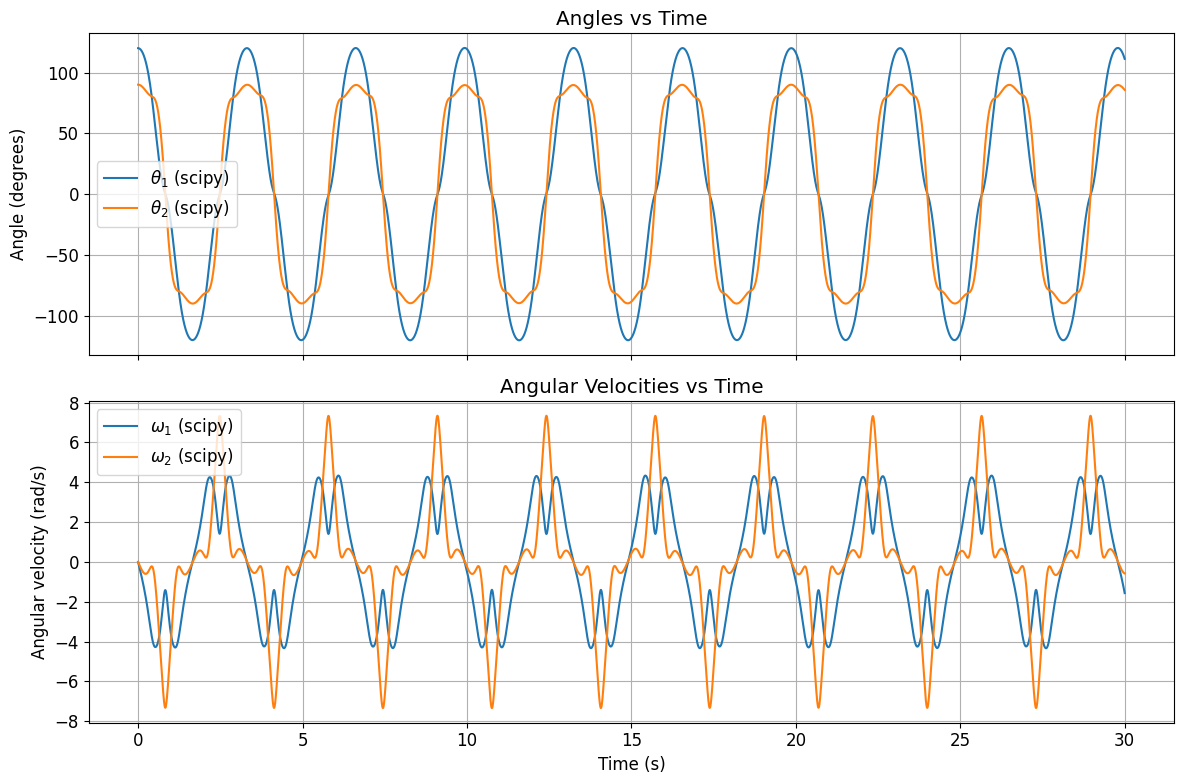

Saved: angles_and_velocities.png


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t_sc, np.degrees(th1_sc), color='tab:blue', label=r'$\theta_1$ (scipy)')
axes[0].plot(t_sc, np.degrees(th2_sc), color='tab:orange', label=r'$\theta_2$ (scipy)')
axes[0].set_ylabel('Angle (degrees)')
axes[0].set_title('Angles vs Time')
axes[0].legend()

axes[1].plot(t_sc, w1_sc, color='tab:blue', label=r'$\omega_1$ (scipy)')
axes[1].plot(t_sc, w2_sc, color='tab:orange', label=r'$\omega_2$ (scipy)')
axes[1].set_ylabel('Angular velocity (rad/s)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Angular Velocities vs Time')
axes[1].legend()

plt.tight_layout()
plt.savefig('angles_and_velocities.png', dpi=120)
plt.show()
print('Saved: angles_and_velocities.png')

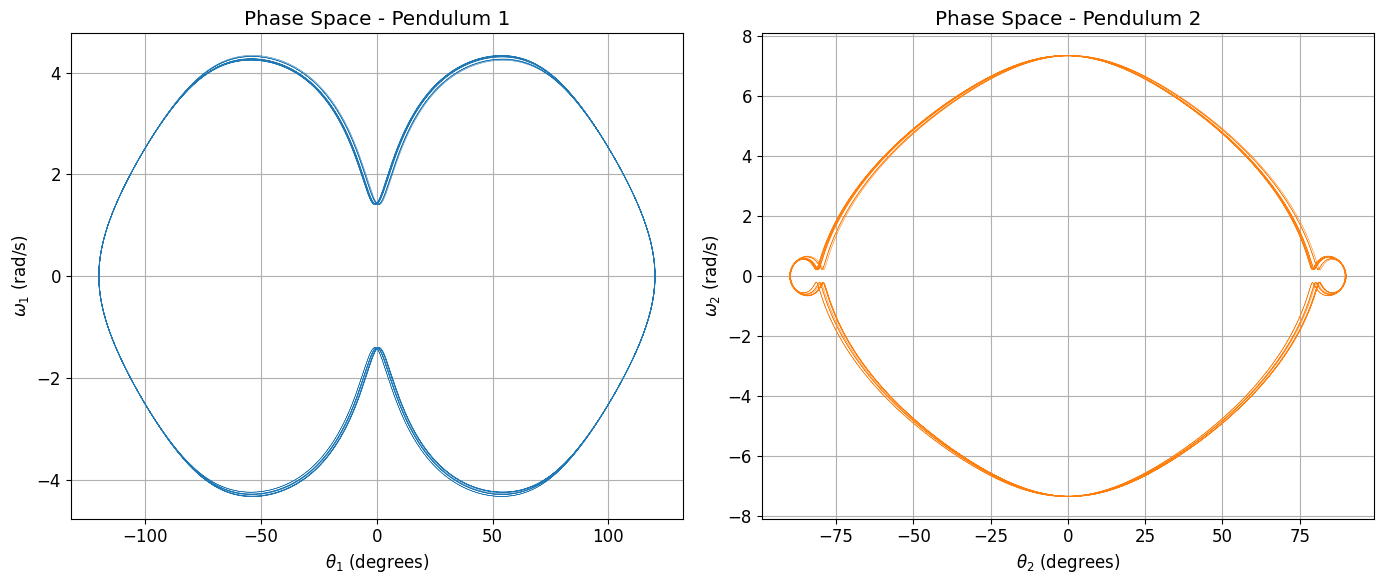

Saved: phase_space.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(np.degrees(th1_sc), w1_sc, color='tab:blue', lw=0.4)
axes[0].set_xlabel(r'$\theta_1$ (degrees)')
axes[0].set_ylabel(r'$\omega_1$ (rad/s)')
axes[0].set_title('Phase Space - Pendulum 1')

axes[1].plot(np.degrees(th2_sc), w2_sc, color='tab:orange', lw=0.4)
axes[1].set_xlabel(r'$\theta_2$ (degrees)')
axes[1].set_ylabel(r'$\omega_2$ (rad/s)')
axes[1].set_title('Phase Space - Pendulum 2')

plt.tight_layout()
plt.savefig('phase_space.png', dpi=120)
plt.show()
print('Saved: phase_space.png')

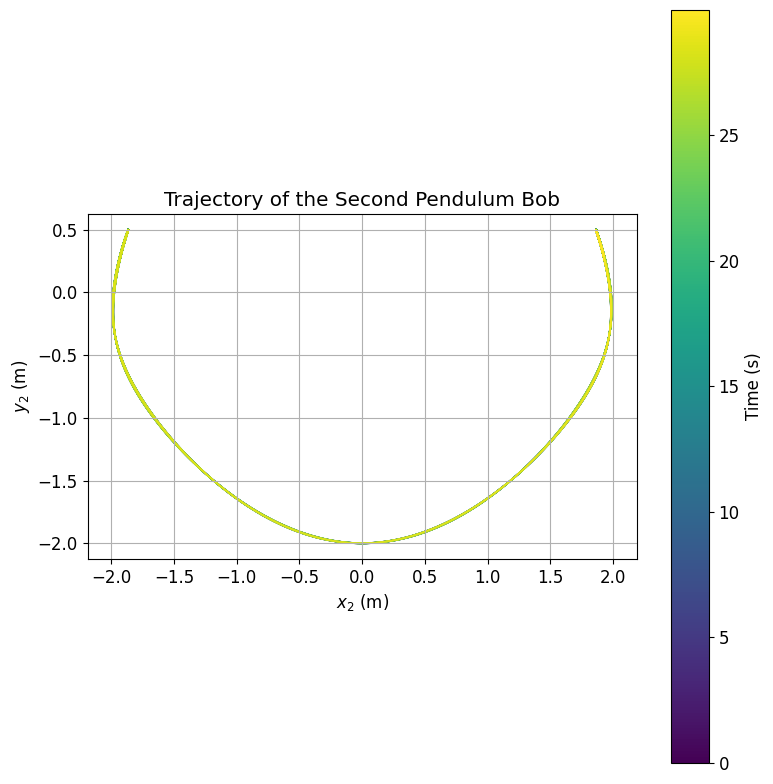

Saved: trajectory_bob2.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(x2_sc, y2_sc, c=t_sc, cmap='viridis', s=0.1)
ax.set_xlabel('$x_2$ (m)')
ax.set_ylabel('$y_2$ (m)')
ax.set_title('Trajectory of the Second Pendulum Bob')
ax.set_aspect('equal')
cb = fig.colorbar(sc, ax=ax)
cb.set_label('Time (s)')
plt.tight_layout()
plt.savefig('trajectory_bob2.png', dpi=120)
plt.show()
print('Saved: trajectory_bob2.png')

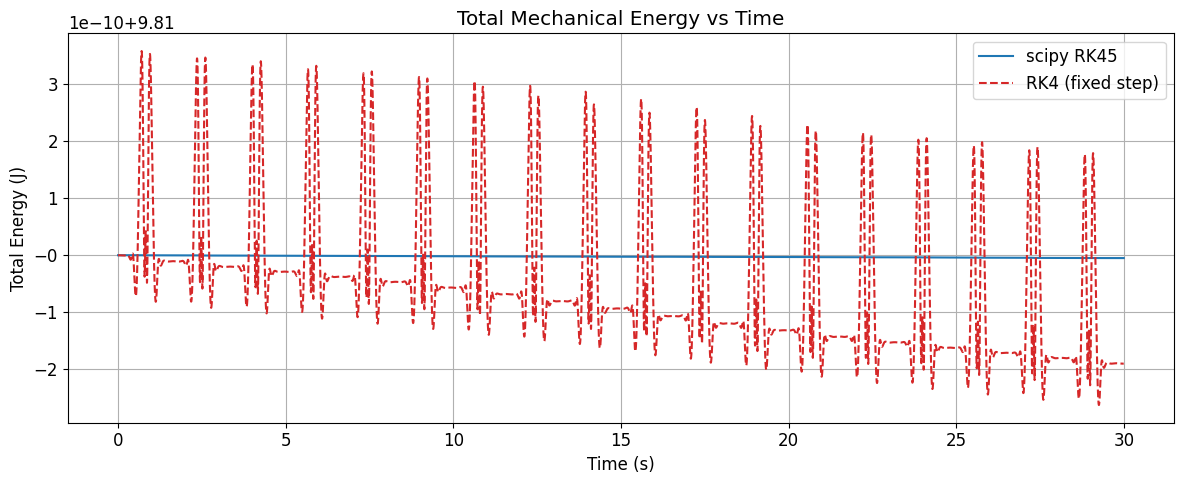

E0 (scipy) = 9.81000000 J
E0 (RK4)   = 9.81000000 J
Max |dE/E0| scipy = 5.13e-13
Max |dE/E0| RK4   = 3.65e-11


In [10]:
def total_energy(th1, w1, th2, w2, m1=m1, m2=m2, l1=l1, l2=l2, g=g):
    """Compute total mechanical energy of the double pendulum."""
    T = (0.5*m1*l1**2*w1**2
       + 0.5*m2*(l1**2*w1**2 + l2**2*w2**2
                 + 2*l1*l2*w1*w2*np.cos(th1-th2)))
    V = -(m1+m2)*g*l1*np.cos(th1) - m2*g*l2*np.cos(th2)
    return T + V

E_sc = total_energy(th1_sc, w1_sc, th2_sc, w2_sc)
E_rk = total_energy(th1_rk, w1_rk, th2_rk, w2_rk)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_sc, E_sc, label='scipy RK45', color='tab:blue')
ax.plot(t_rk, E_rk, label='RK4 (fixed step)', color='tab:red', ls='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Total Energy (J)')
ax.set_title('Total Mechanical Energy vs Time')
ax.legend()
plt.tight_layout()
plt.savefig('energy_vs_time.png', dpi=120)
plt.show()

print(f'E0 (scipy) = {E_sc[0]:.8f} J')
print(f'E0 (RK4)   = {E_rk[0]:.8f} J')
print(f'Max |dE/E0| scipy = {np.max(np.abs((E_sc - E_sc[0])/E_sc[0])):.2e}')
print(f'Max |dE/E0| RK4   = {np.max(np.abs((E_rk - E_rk[0])/E_rk[0])):.2e}')

## 6. 3-D Visualization

A parametric curve $(\theta_1(t),\; \theta_2(t),\; t)$ in three-dimensional space.

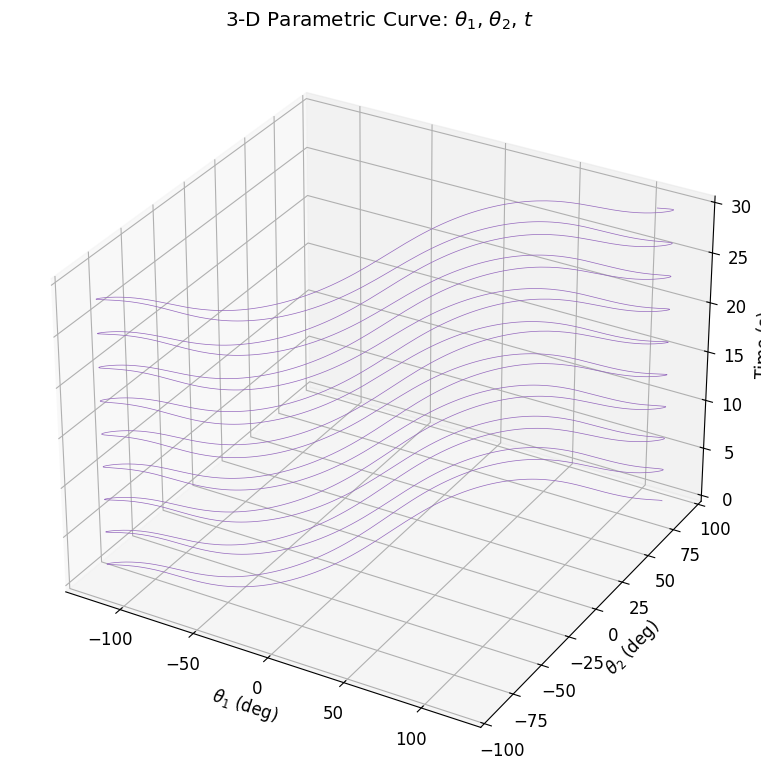

Saved: 3d_parametric.png


In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
step = 10  # downsample for clarity
ax.plot(np.degrees(th1_sc[::step]),
        np.degrees(th2_sc[::step]),
        t_sc[::step],
        lw=0.5, color='tab:purple')
ax.set_xlabel(r'$\theta_1$ (deg)')
ax.set_ylabel(r'$\theta_2$ (deg)')
ax.set_zlabel('Time (s)')
ax.set_title(r'3-D Parametric Curve: $\theta_1$, $\theta_2$, $t$')
plt.tight_layout()
plt.savefig('3d_parametric.png', dpi=120)
plt.show()
print('Saved: 3d_parametric.png')

## 7. Animation

We generate key frames of the double pendulum swinging and display them inline. A full `FuncAnimation` is also constructed and saved as a GIF (if `pillow` is available) for offline viewing.

In [12]:
# Key-frame rendering
frame_dir = 'dp_frames'
os.makedirs(frame_dir, exist_ok=True)

# Downsample to ~200 frames for animation
skip = max(1, len(t_sc) // 200)
t_anim   = t_sc[::skip]
x1_anim  = x1_sc[::skip]
y1_anim  = y1_sc[::skip]
x2_anim  = x2_sc[::skip]
y2_anim  = y2_sc[::skip]

trail_len = 40  # number of trailing points

def draw_frame(i, save=False):
    """Draw a single frame of the double-pendulum animation."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.set_aspect('equal')
    ax.set_title(f'Double Pendulum   t = {t_anim[i]:.2f} s')
    ax.grid(True, alpha=0.3)

    # Trailing path
    start = max(0, i - trail_len)
    ax.plot(x2_anim[start:i+1], y2_anim[start:i+1],
            '-', color='tab:orange', alpha=0.5, lw=1)

    # Rods
    ax.plot([0, x1_anim[i]], [0, y1_anim[i]], 'k-', lw=2)
    ax.plot([x1_anim[i], x2_anim[i]], [y1_anim[i], y2_anim[i]], 'k-', lw=2)

    # Bobs
    ax.plot(0, 0, 'ko', ms=8)
    ax.plot(x1_anim[i], y1_anim[i], 'o', color='tab:blue', ms=10, zorder=5)
    ax.plot(x2_anim[i], y2_anim[i], 'o', color='tab:red', ms=10, zorder=5)

    if save:
        fpath = os.path.join(frame_dir, f'frame_{i:04d}.png')
        fig.savefig(fpath, dpi=80)
    plt.close(fig)

# Save a handful of key frames and display them
key_indices = np.linspace(0, len(t_anim)-1, 8, dtype=int)
for idx in key_indices:
    draw_frame(idx, save=True)

print(f"Key frames saved to '{frame_dir}/'")

Key frames saved to 'dp_frames/'


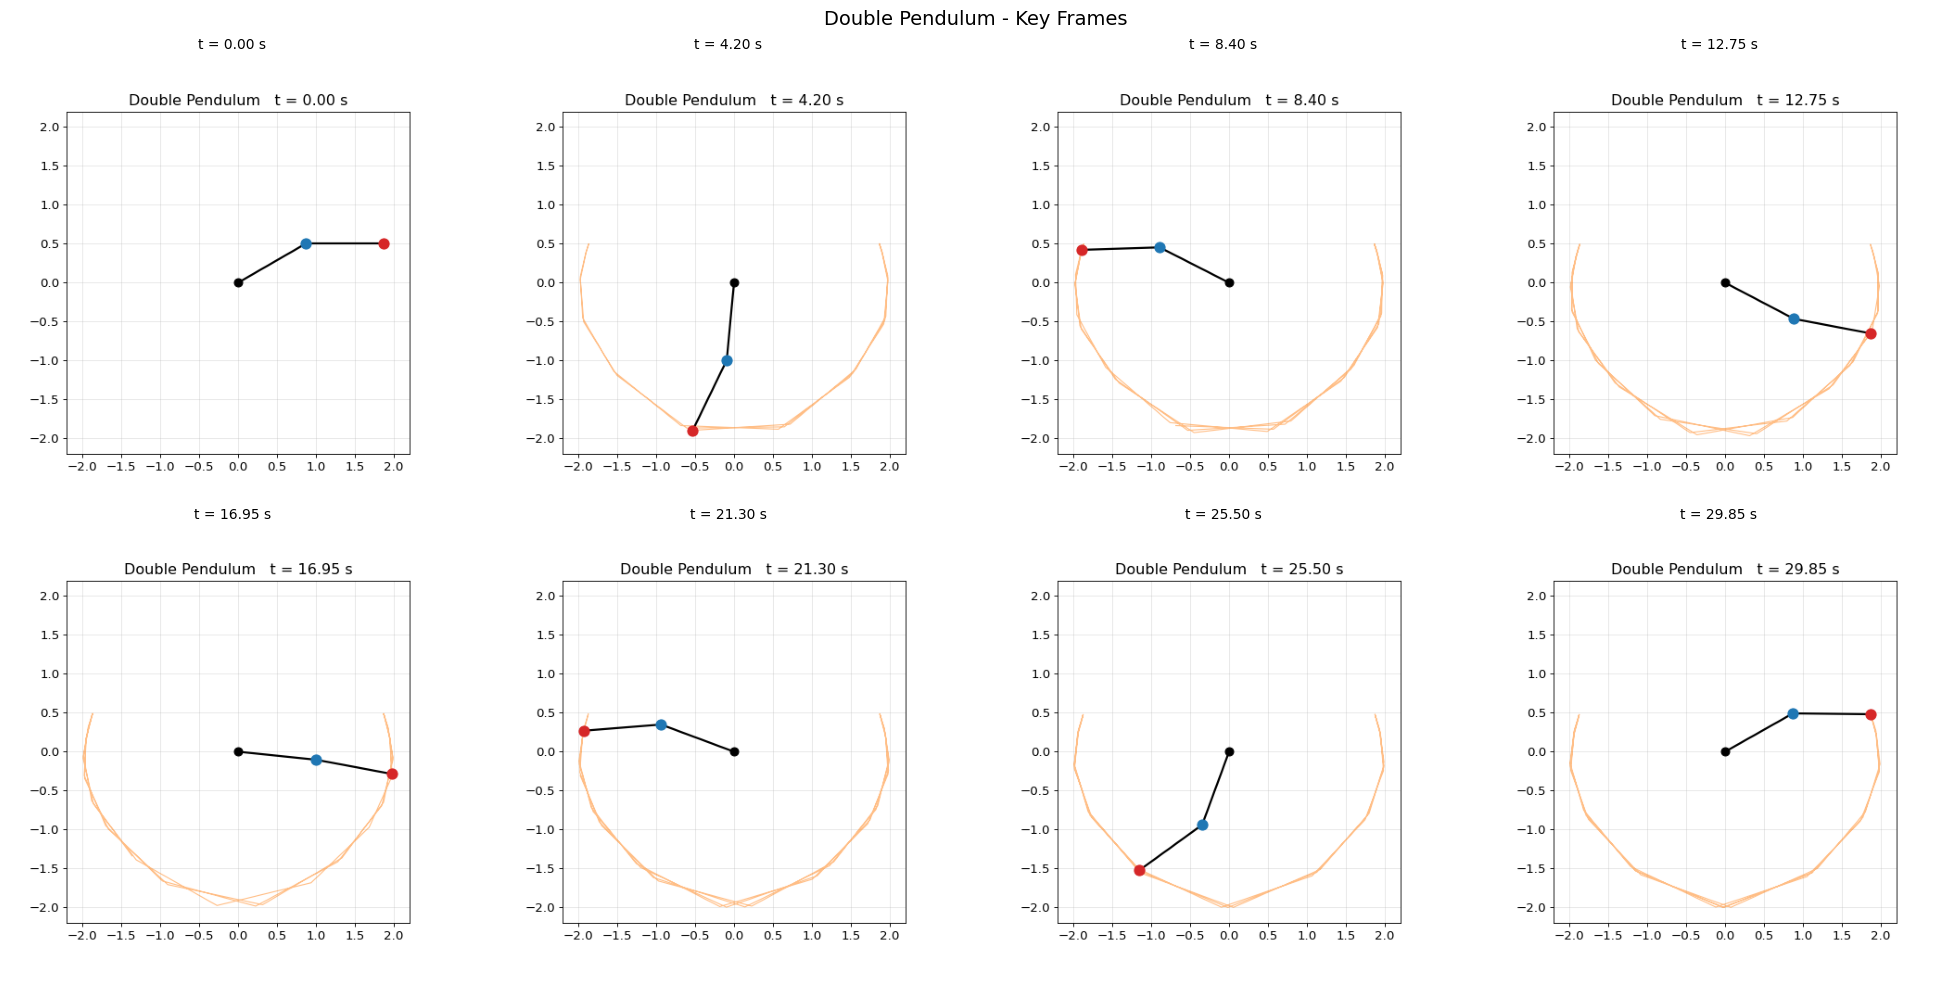

Saved: key_frames.png


In [13]:
# Display key frames inline
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, idx in zip(axes.flat, key_indices):
    img = plt.imread(os.path.join(frame_dir, f'frame_{idx:04d}.png'))
    ax.imshow(img)
    ax.set_title(f't = {t_anim[idx]:.2f} s', fontsize=10)
    ax.axis('off')
plt.suptitle('Double Pendulum - Key Frames', fontsize=14)
plt.tight_layout()
plt.savefig('key_frames.png', dpi=100)
plt.show()
print('Saved: key_frames.png')

In [14]:
# Build full FuncAnimation and save as GIF
fig_anim, ax_anim = plt.subplots(figsize=(6, 6))

def init_anim():
    ax_anim.set_xlim(-2.2, 2.2)
    ax_anim.set_ylim(-2.2, 2.2)
    ax_anim.set_aspect('equal')
    return []

def update_anim(i):
    ax_anim.cla()
    ax_anim.set_xlim(-2.2, 2.2)
    ax_anim.set_ylim(-2.2, 2.2)
    ax_anim.set_aspect('equal')
    ax_anim.grid(True, alpha=0.3)
    ax_anim.set_title(f'Double Pendulum   t = {t_anim[i]:.2f} s')

    start = max(0, i - trail_len)
    ax_anim.plot(x2_anim[start:i+1], y2_anim[start:i+1],
                 '-', color='tab:orange', alpha=0.5, lw=1)
    ax_anim.plot([0, x1_anim[i]], [0, y1_anim[i]], 'k-', lw=2)
    ax_anim.plot([x1_anim[i], x2_anim[i]], [y1_anim[i], y2_anim[i]], 'k-', lw=2)
    ax_anim.plot(0, 0, 'ko', ms=8)
    ax_anim.plot(x1_anim[i], y1_anim[i], 'o', color='tab:blue', ms=10, zorder=5)
    ax_anim.plot(x2_anim[i], y2_anim[i], 'o', color='tab:red', ms=10, zorder=5)
    return []

anim = animation.FuncAnimation(fig_anim, update_anim, init_func=init_anim,
                                frames=len(t_anim), interval=50, blit=True)
try:
    anim.save('double_pendulum.gif', writer='pillow', fps=20)
    print('Animation saved: double_pendulum.gif')
except Exception as e:
    print(f'Could not save GIF: {e}')
plt.close(fig_anim)

Animation saved: double_pendulum.gif


## 8. Error Analysis

We compare the **scipy `solve_ivp` (RK45, adaptive)** solution with our **fixed-step RK4** implementation. Key diagnostics:

1. **Energy drift** — deviation of total energy from its initial value over time.
2. **Trajectory divergence** — difference in $\theta_1(t)$ and $\theta_2(t)$ between the two solvers.
3. **Relative energy error** — $\bigl|E(t)-E_0\bigr|/|E_0|$.

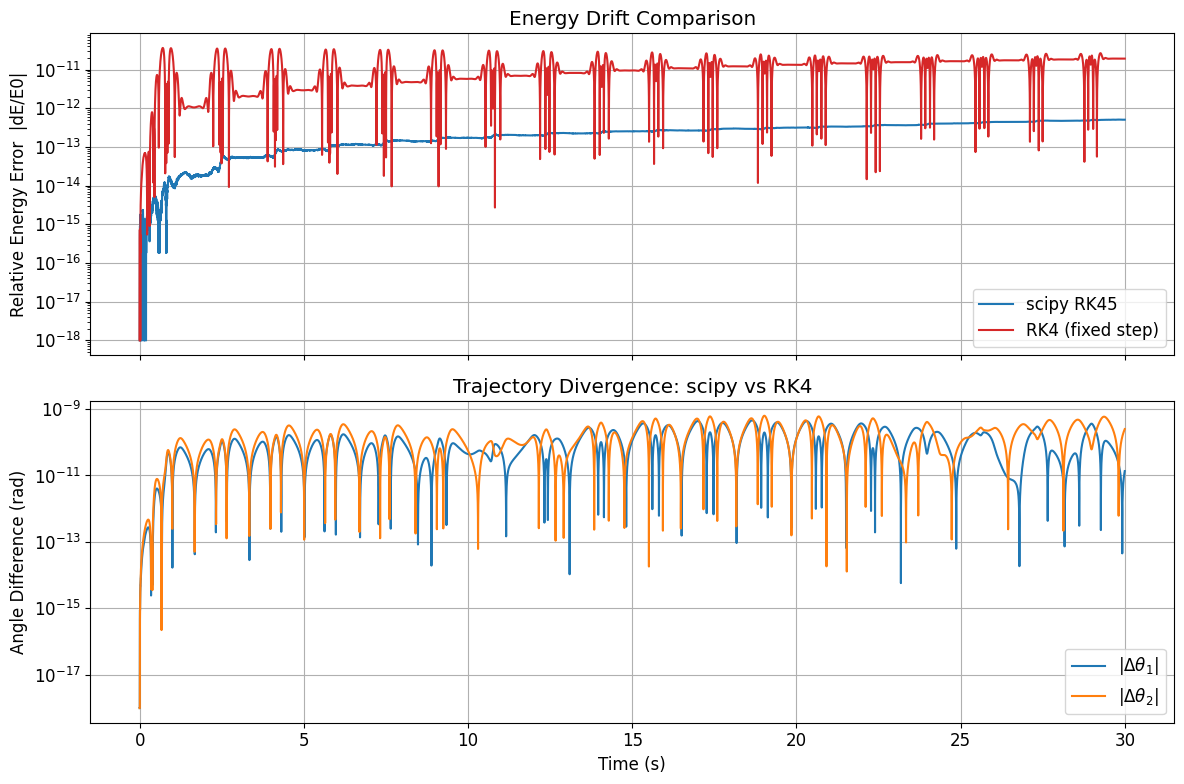

Final |Delta_theta1| = 1.353628e-11 rad
Final |Delta_theta2| = 2.488607e-10 rad


In [15]:
# Energy drift
n_common = min(len(t_sc), len(t_rk))
t_common = t_sc[:n_common]

rel_err_sc = np.abs((E_sc[:n_common] - E_sc[0]) / E_sc[0])
rel_err_rk = np.abs((E_rk[:n_common] - E_rk[0]) / E_rk[0])

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].semilogy(t_common, rel_err_sc + 1e-18, label='scipy RK45', color='tab:blue')
axes[0].semilogy(t_common, rel_err_rk + 1e-18, label='RK4 (fixed step)', color='tab:red')
axes[0].set_ylabel('Relative Energy Error  |dE/E0|')
axes[0].set_title('Energy Drift Comparison')
axes[0].legend()

# Trajectory divergence
diff_th1 = np.abs(th1_sc[:n_common] - th1_rk[:n_common])
diff_th2 = np.abs(th2_sc[:n_common] - th2_rk[:n_common])

axes[1].semilogy(t_common, diff_th1 + 1e-18, label=r'$|\Delta\theta_1|$', color='tab:blue')
axes[1].semilogy(t_common, diff_th2 + 1e-18, label=r'$|\Delta\theta_2|$', color='tab:orange')
axes[1].set_ylabel('Angle Difference (rad)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Trajectory Divergence: scipy vs RK4')
axes[1].legend()

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=120)
plt.show()

print(f'Final |Delta_theta1| = {diff_th1[-1]:.6e} rad')
print(f'Final |Delta_theta2| = {diff_th2[-1]:.6e} rad')

### Discussion

- The **adaptive RK45** integrator maintains tighter energy conservation than fixed-step RK4 because it adjusts step size to meet prescribed tolerances.
- Both solvers eventually diverge from each other due to the chaotic nature of the system — even round-off-level differences grow exponentially.
- Reducing the RK4 step size (`dt`) improves accuracy but increases computation time quadratically.
- For chaotic systems, **long-term pointwise accuracy** is unattainable regardless of method; only **statistical** or **qualitative** properties (e.g., phase-space structure, Lyapunov exponents) are meaningful long-term indicators.

## 9. Sensitivity to Initial Conditions

A defining feature of chaos: two trajectories that start with an infinitesimal angular difference diverge exponentially. We quantify this by computing the **maximum Lyapunov exponent** estimate.

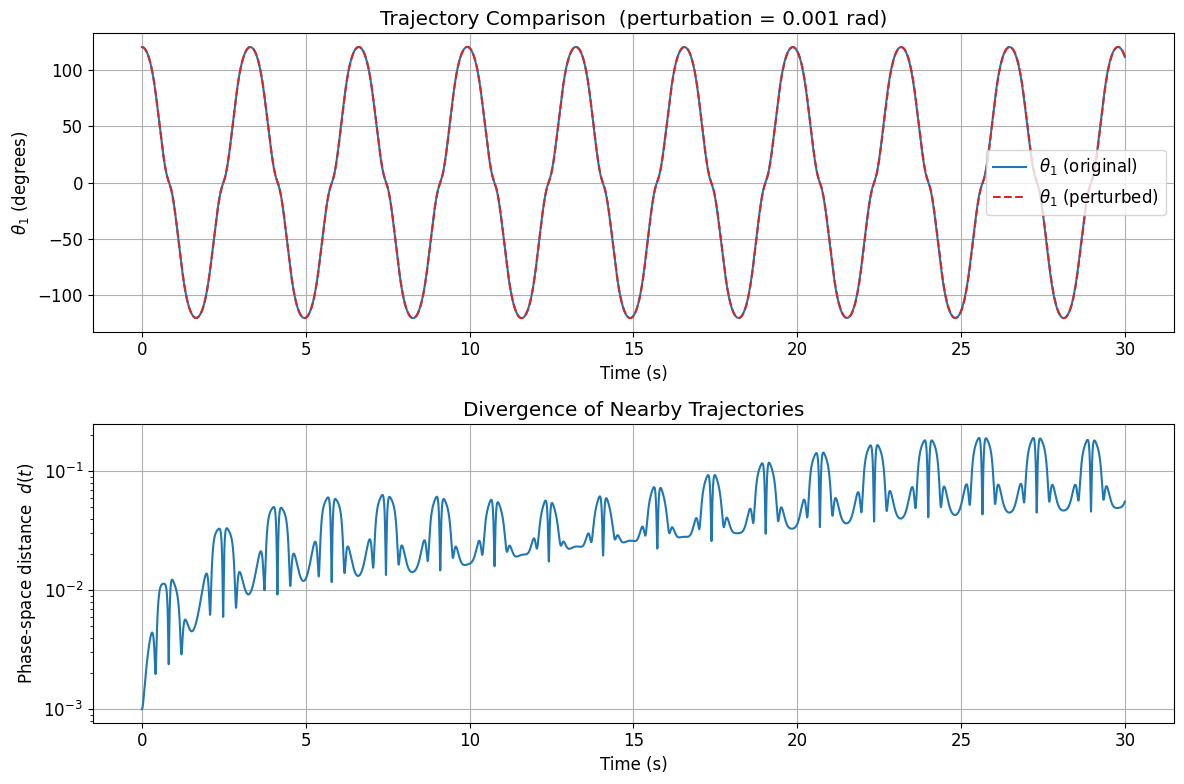

In [16]:
# Two runs with a tiny perturbation
eps = 1e-3  # perturbation in theta1 (rad)
y0_pert = [theta1_0 + eps, omega1_0, theta2_0, omega2_0]

sol_pert = solve_ivp(
    double_pendulum_derivs, (t_start, t_end), y0_pert,
    method='RK45', t_eval=t_eval_scipy,
    rtol=1e-10, atol=1e-12, max_step=dt
)

# Phase-space distance
delta_th1 = sol_scipy.y[0] - sol_pert.y[0]
delta_th2 = sol_scipy.y[2] - sol_pert.y[2]
delta_w1  = sol_scipy.y[1] - sol_pert.y[1]
delta_w2  = sol_scipy.y[3] - sol_pert.y[3]
dist = np.sqrt(delta_th1**2 + delta_th2**2 + delta_w1**2 + delta_w2**2)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(t_sc, np.degrees(sol_scipy.y[0]), label=r'$\theta_1$ (original)', color='tab:blue')
axes[0].plot(t_sc, np.degrees(sol_pert.y[0]),  label=r'$\theta_1$ (perturbed)', color='tab:red', ls='--')
axes[0].set_ylabel(r'$\theta_1$ (degrees)')
axes[0].set_xlabel('Time (s)')
axes[0].set_title(f'Trajectory Comparison  (perturbation = {eps} rad)')
axes[0].legend()

axes[1].semilogy(t_sc, dist)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Phase-space distance  $d(t)$')
axes[1].set_title('Divergence of Nearby Trajectories')

plt.tight_layout()
plt.savefig('sensitivity.png', dpi=120)
plt.show()

In [17]:
# Lyapunov exponent estimate
# lambda ~ (1/t) ln(d(t)/d(0))  for large t where exponential growth dominates

d0 = dist[0]
# Use a window where growth is clearly exponential
mask = (t_sc > 1.0) & (t_sc < 15.0) & (dist > 0)
if np.any(mask):
    lyap_estimates = np.log(dist[mask] / d0) / t_sc[mask]
    lyap_exp = np.median(lyap_estimates)
    print(f'Initial separation  d0 = {d0:.6e}')
    print(f'Estimated max Lyapunov exponent  lambda ~ {lyap_exp:.4f} /s')
    print(f'Positive lambda confirms chaotic behavior.')
else:
    print('Could not estimate Lyapunov exponent.')

# Linear fit to log(d) vs t
mask_fit = (t_sc > 0.5) & (t_sc < 10.0) & (dist > 0)
if np.sum(mask_fit) > 10:
    coeffs = np.polyfit(t_sc[mask_fit], np.log(dist[mask_fit]), 1)
    print(f'Linear fit:  log(d) ~ {coeffs[0]:.4f} * t + {coeffs[1]:.4f}')
    print(f'Slope gives lambda ~ {coeffs[0]:.4f} /s')

Initial separation  d0 = 1.000000e-03
Estimated max Lyapunov exponent  lambda ~ 0.4044 /s
Positive lambda confirms chaotic behavior.
Linear fit:  log(d) ~ 0.1324 * t + -4.6251
Slope gives lambda ~ 0.1324 /s


### Interpretation

- A **positive Lyapunov exponent** ($\lambda > 0$) is the quantitative hallmark of chaos.
- It means nearby trajectories separate at a rate $\sim e^{\lambda t}$, making long-term deterministic prediction impossible.
- The value of $\lambda$ depends on the initial conditions and system parameters, but the sign is robustly positive for large-amplitude oscillations of the double pendulum.

## 10. Boundary and Special Cases

### Small-Angle Approximation

For $|\theta_i| \ll 1$, $\sin\theta \approx \theta$ and $\cos\theta \approx 1$, reducing the system to coupled **linear** ODEs that can be solved analytically in terms of normal modes. We compare the linearized solution to the full nonlinear numerical solution.

Normal mode frequencies: w1 = 2.3972 rad/s, w2 = 5.7874 rad/s


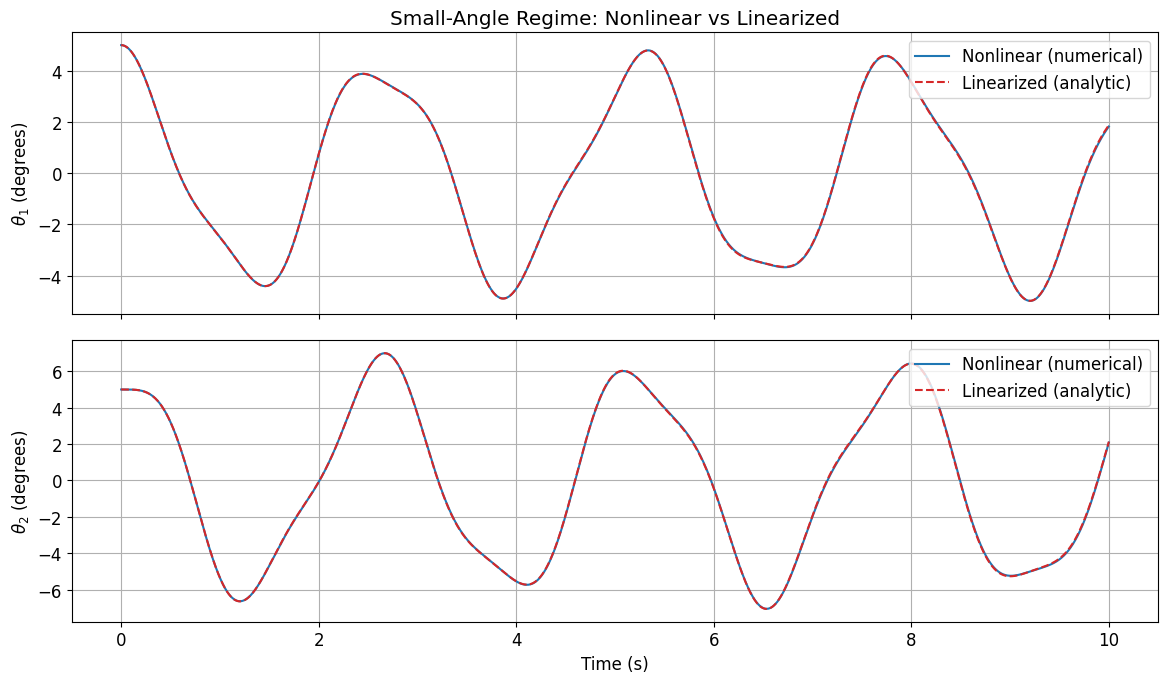

At small angles the linearized and nonlinear solutions agree closely.


In [18]:
# Small-angle comparison
theta_small = np.radians(5)  # 5 degrees - well within linear regime
y0_small = [theta_small, 0.0, theta_small, 0.0]

t_short = np.arange(0, 10, dt)

# Full nonlinear solve
sol_nl = solve_ivp(double_pendulum_derivs, (0, 10), y0_small,
                   method='RK45', t_eval=t_short, rtol=1e-12, atol=1e-14)

# Linearized equations (equal masses, equal lengths simplification)
# M q'' + K q = 0  where q = [theta1, theta2]
# M = [[2, 1],[1, 1]]  K = [[2g/l, 0],[0, g/l]]  (for m1=m2=m, l1=l2=l)
M_mat = np.array([[2.0, 1.0], [1.0, 1.0]])
K_mat = np.array([[2*g/l1, 0.0], [0.0, g/l2]])

# Eigenvalue problem: (K - omega^2 M) v = 0
from scipy.linalg import eigh
eigvals, eigvecs = eigh(K_mat, M_mat)
omega_modes = np.sqrt(eigvals)
print(f'Normal mode frequencies: w1 = {omega_modes[0]:.4f} rad/s, w2 = {omega_modes[1]:.4f} rad/s')

# General solution: q(t) = sum (A_n cos(w_n t) + B_n sin(w_n t)) v_n
# With q(0) = [theta_s, theta_s], q'(0) = [0, 0] -> B_n = 0
# A_n = (v_n^T M q0) / (v_n^T M v_n)  (eigvecs are M-orthogonal from eigh)
q0 = np.array([theta_small, theta_small])
A = np.zeros(2)
for n in range(2):
    v = eigvecs[:, n]
    A[n] = v @ M_mat @ q0 / (v @ M_mat @ v)

th1_lin = np.zeros_like(t_short)
th2_lin = np.zeros_like(t_short)
for n in range(2):
    th1_lin += A[n] * eigvecs[0, n] * np.cos(omega_modes[n] * t_short)
    th2_lin += A[n] * eigvecs[1, n] * np.cos(omega_modes[n] * t_short)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t_short, np.degrees(sol_nl.y[0]), label='Nonlinear (numerical)', color='tab:blue')
axes[0].plot(t_short, np.degrees(th1_lin), '--', label='Linearized (analytic)', color='tab:red')
axes[0].set_ylabel(r'$\theta_1$ (degrees)')
axes[0].set_title('Small-Angle Regime: Nonlinear vs Linearized')
axes[0].legend()

axes[1].plot(t_short, np.degrees(sol_nl.y[2]), label='Nonlinear (numerical)', color='tab:blue')
axes[1].plot(t_short, np.degrees(th2_lin), '--', label='Linearized (analytic)', color='tab:red')
axes[1].set_ylabel(r'$\theta_2$ (degrees)')
axes[1].set_xlabel('Time (s)')
axes[1].legend()

plt.tight_layout()
plt.savefig('small_angle.png', dpi=120)
plt.show()
print('At small angles the linearized and nonlinear solutions agree closely.')

### Special Cases Discussion

| Case | Behavior |
|------|----------|
| **Equal masses & lengths** ($m_1=m_2$, $l_1=l_2$) | The two normal-mode frequencies in the linearized limit are $\omega_\pm = \sqrt{g/l\,(2 \pm \sqrt{2})}$. |
| **Zero initial velocity** ($\dot\theta_{1,2}=0$) | Motion starts from rest; the system immediately begins to accelerate under gravity. |
| **Very small angles** ($\theta \ll 1$) | Reduces to coupled harmonic oscillators — periodic, non-chaotic motion. |
| **One mass → 0** ($m_2 \to 0$) | The second rod becomes massless; pendulum 1 behaves as a simple pendulum. |
| **Very large angles** | Deep chaotic regime with flips and irregular oscillations. |

## 11. Conclusions

1. **Lagrangian mechanics** provides an elegant derivation of the equations of motion for the double pendulum, yielding two coupled nonlinear second-order ODEs.

2. **Numerical integration** — both `scipy`'s adaptive RK45 and a hand-written fixed-step RK4 — successfully tracks the motion, with the adaptive solver offering superior energy conservation.

3. **Chaos is confirmed**: a positive Lyapunov exponent demonstrates exponential sensitivity to initial conditions. Trajectories that start $10^{-3}$ rad apart diverge to $\mathcal{O}(1)$ differences within seconds.

4. **Energy conservation** serves as a powerful diagnostic: energy drift quantifies the accumulation of numerical error.

5. **Small-angle approximation** yields linear, analytically solvable equations that agree with the full nonlinear solution at low amplitudes, confirming the validity of both approaches in their respective domains.

6. The double pendulum is a compelling demonstration that **deterministic does not mean predictable** — the core insight of classical chaos theory.

---

*Notebook created for Computational Physics Final Project.*